# 04 Additional Robustness and Spatial Comparisons

This notebook compares record- and unit-weighted PTAL distributions, constructs borough-relative baselines, stratifies deprivation results by Inner and Outer London, and audits missing spatial data.


## Setup


In [7]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path(".")
BASE = PROJECT_ROOT

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HOUSING_PATH = (
    OUTPUT_DIR /
    "pld_completed_housing_with_ptal_main_2015_2025.gpkg"
)

CORE_PATH = (
    OUTPUT_DIR /
    "pld_core_main_2015_2025.csv"
)

PTAL_PATH = BASE / "PTAL_2023_Grid_100mx100m_Data.geojson"
BOROUGH_PATH = BASE / "London_Boroughs.gpkg"
ONSPD_PATH = BASE / "ONSPD_FEB_2026_UK.csv"

for label, path in {
    "Final housing GeoPackage": HOUSING_PATH,
    "Core sample export": CORE_PATH,
    "PTAL grid": PTAL_PATH,
    "Borough boundaries": BOROUGH_PATH,
    "ONSPD": ONSPD_PATH,
}.items():
    print(f"{label}: {path.exists()} — {path.resolve()}")

Final housing GeoPackage: True — C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\outputs\pld_completed_housing_with_ptal_main_2015_2025.gpkg
Core sample export: True — C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\outputs\pld_core_main_2015_2025.csv
PTAL grid: True — C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\PTAL_2023_Grid_100mx100m_Data.geojson
Borough boundaries: True — C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\London_Boroughs.gpkg
ONSPD: True — C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\ONSPD_FEB_2026_UK.csv


In [8]:
# Load the final housing data
housing_all = gpd.read_file(HOUSING_PATH)

required_cols = {
    "LPA Number", "completed_units", "PTAL_2023", "ptal_band",
    "ptal_medium_high", "ptal_high", "completion_financial_year",
    "borough_spatial", "lsoa11cd", "geometry"
}
missing_cols = required_cols.difference(housing_all.columns)
if missing_cols:
    raise ValueError(f"Missing required housing columns: {sorted(missing_cols)}")

housing = housing_all[housing_all["PTAL_2023"].notna()].copy()
housing["completed_units"] = pd.to_numeric(housing["completed_units"], errors="coerce")
housing = housing[housing["completed_units"].notna() & (housing["completed_units"] > 0)].copy()

print("All geocoded rows:", len(housing_all))
print("PTAL-valid rows:", len(housing))
print("PTAL-valid units:", housing["completed_units"].sum())
print("CRS:", housing.crs)


All geocoded rows: 25852
PTAL-valid rows: 25829
PTAL-valid units: 225104.0
CRS: EPSG:27700


In [9]:
# Helper functions and category orders
PTAL_CATEGORY_ORDER = ["0", "1a", "1b", "2", "3", "4", "5", "6a", "6b"]
PTAL_BAND_ORDER = ["Low", "Medium", "High"]
IMD_ORDER = [
    "Q1 most deprived",
    "Q2",
    "Q3",
    "Q4",
    "Q5 least deprived",
]

def normalise_ptal(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().lower()
    if text.endswith(".0"):
        text = text[:-2]
    return text

def find_col(columns, candidates):
    exact = {str(c): c for c in columns}
    lower = {str(c).lower(): c for c in columns}
    for candidate in candidates:
        if candidate in exact:
            return exact[candidate]
        if candidate.lower() in lower:
            return lower[candidate.lower()]
    return None

housing["ptal_category"] = housing["PTAL_2023"].map(normalise_ptal)
housing["ptal_category"] = pd.Categorical(
    housing["ptal_category"],
    categories=PTAL_CATEGORY_ORDER,
    ordered=True
)
housing["ptal_band"] = pd.Categorical(
    housing["ptal_band"],
    categories=PTAL_BAND_ORDER,
    ordered=True
)


## 1. Record-weighted versus unit-weighted PTAL distribution

This checks whether the headline result is driven by large schemes. The record share treats each planning record equally; the unit share weights each record by the number of completed homes.


In [10]:
weighting_comparison = (
    housing
    .groupby("ptal_band", observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum")
    )
    .reindex(PTAL_BAND_ORDER)
    .reset_index()
)

weighting_comparison["record_share"] = (
    weighting_comparison["records"] / weighting_comparison["records"].sum()
)
weighting_comparison["unit_share"] = (
    weighting_comparison["completed_units"] /
    weighting_comparison["completed_units"].sum()
)
weighting_comparison["unit_minus_record_pp"] = (
    100 * (weighting_comparison["unit_share"] - weighting_comparison["record_share"])
)

weighting_comparison.to_csv(
    OUTPUT_DIR / "04_record_vs_unit_weighted_ptal.csv",
    index=False
)
weighting_comparison


,ptal_band,records,completed_units,record_share,unit_share,unit_minus_record_pp
0,Low,9142,63459.0,0.353943,0.281910,-7.203355
1,Medium,9426,72077.0,0.364939,0.320194,-4.474441
2,High,7261,89568.0,0.281118,0.397896,11.677796


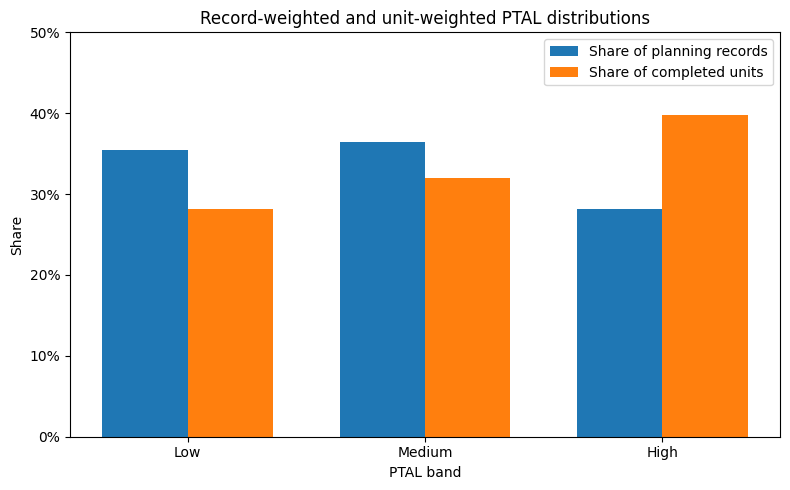

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(weighting_comparison))
width = 0.36

ax.bar(
    x - width / 2,
    weighting_comparison["record_share"],
    width,
    label="Share of planning records"
)
ax.bar(
    x + width / 2,
    weighting_comparison["unit_share"],
    width,
    label="Share of completed units"
)

ax.set_xticks(x)
ax.set_xticklabels(weighting_comparison["ptal_band"].astype(str))
ax.set_ylim(0, 0.5)
ax.set_xlabel("PTAL band")
ax.set_ylabel("Share")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("Record-weighted and unit-weighted PTAL distributions")
ax.legend()

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04a_record_vs_unit_weighted_ptal.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [12]:
# Optional detailed table using all nine PTAL categories
ptal_category_comparison = (
    housing
    .groupby("ptal_category", observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum")
    )
    .reindex(PTAL_CATEGORY_ORDER)
    .reset_index()
)

ptal_category_comparison["record_share"] = (
    ptal_category_comparison["records"] /
    ptal_category_comparison["records"].sum()
)
ptal_category_comparison["unit_share"] = (
    ptal_category_comparison["completed_units"] /
    ptal_category_comparison["completed_units"].sum()
)

ptal_category_comparison.to_csv(
    OUTPUT_DIR / "04_full_ptal_category_weighting_comparison.csv",
    index=False
)
ptal_category_comparison


,ptal_category,records,completed_units,record_share,unit_share
0,0,232,1410.0,0.008982,0.006264
1,1a,562,3270.0,0.021758,0.014527
2,1b,2271,17112.0,0.087924,0.076018
3,2,6077,41667.0,0.235278,0.185101
4,3,5468,41374.0,0.211700,0.183799
5,4,3958,30703.0,0.153239,0.136395
6,5,2624,28919.0,0.101591,0.128470
7,6a,3083,36584.0,0.119362,0.162520
8,6b,1554,24065.0,0.060165,0.106906


## 2. Borough-relative PTAL baseline

The existing borough chart compares absolute Medium/High shares. This section also compares each borough's completed-unit share with the proportion of that borough's PTAL grid cells that are Medium/High.

Two new measures are produced:

- `difference_pp`: completed-unit share minus borough grid-cell share, in percentage points.
- `alignment_ratio`: completed-unit share divided by borough grid-cell share.


In [13]:
# Load borough boundaries and the PTAL grid
boroughs = gpd.read_file(BOROUGH_PATH)
ptal_grid = gpd.read_file(PTAL_PATH)

if "name" not in boroughs.columns:
    raise ValueError(f"Expected borough name column 'name'. Found: {boroughs.columns.tolist()}")
if "ons_inner" not in boroughs.columns:
    warnings.warn("Column 'ons_inner' is missing; Inner/Outer analysis will need another classification.")
if "PTAL_2023" not in ptal_grid.columns:
    raise ValueError(f"Expected PTAL column 'PTAL_2023'. Found: {ptal_grid.columns.tolist()}")

boroughs = boroughs.to_crs("EPSG:27700")
ptal_grid = ptal_grid.to_crs("EPSG:27700")

ptal_grid["ptal_category"] = ptal_grid["PTAL_2023"].map(normalise_ptal)
ptal_rank = {category: rank for rank, category in enumerate(PTAL_CATEGORY_ORDER)}
ptal_grid["ptal_rank"] = ptal_grid["ptal_category"].map(ptal_rank)
ptal_grid["grid_medium_high"] = ptal_grid["ptal_rank"] >= ptal_rank["3"]

# Assign every 100 m PTAL cell to a borough using its centroid.
ptal_points = ptal_grid[["PTAL_2023", "ptal_category", "grid_medium_high", "geometry"]].copy()
ptal_points["geometry"] = ptal_points.geometry.centroid

ptal_borough = gpd.sjoin(
    ptal_points,
    boroughs[["name", "ons_inner", "geometry"]],
    how="inner",
    predicate="within"
).drop(columns="index_right")

print("PTAL grid cells:", len(ptal_grid))
print("PTAL cells assigned to boroughs:", len(ptal_borough))
print("Assignment share:", len(ptal_borough) / len(ptal_grid))


PTAL grid cells: 159451
PTAL cells assigned to boroughs: 159451
Assignment share: 1.0


In [14]:
# Housing summary by borough
borough_housing = (
    housing
    .dropna(subset=["borough_spatial"])
    .groupby("borough_spatial")
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum"),
        units_medium_high=(
            "completed_units",
            lambda values: values[
                housing.loc[values.index, "ptal_medium_high"].astype(bool)
            ].sum()
        ),
        units_high=(
            "completed_units",
            lambda values: values[
                housing.loc[values.index, "ptal_high"].astype(bool)
            ].sum()
        )
    )
    .reset_index()
)

borough_housing["completed_share_medium_high"] = (
    borough_housing["units_medium_high"] /
    borough_housing["completed_units"]
)
borough_housing["completed_share_high"] = (
    borough_housing["units_high"] /
    borough_housing["completed_units"]
)

# PTAL-grid summary by borough
borough_grid = (
    ptal_borough
    .groupby(["name", "ons_inner"], dropna=False)
    .agg(
        grid_cells=("PTAL_2023", "size"),
        grid_cells_medium_high=("grid_medium_high", "sum")
    )
    .reset_index()
)
borough_grid["grid_share_medium_high"] = (
    borough_grid["grid_cells_medium_high"] /
    borough_grid["grid_cells"]
)

borough_relative = borough_housing.merge(
    borough_grid,
    left_on="borough_spatial",
    right_on="name",
    how="left",
    validate="one_to_one"
)

print("Housing boroughs without a grid match:")
print(
    borough_relative.loc[
        borough_relative["grid_share_medium_high"].isna(),
        "borough_spatial"
    ].tolist()
)

borough_relative["difference_pp"] = 100 * (
    borough_relative["completed_share_medium_high"] -
    borough_relative["grid_share_medium_high"]
)
borough_relative["alignment_ratio"] = np.where(
    borough_relative["grid_share_medium_high"] > 0,
    borough_relative["completed_share_medium_high"] /
    borough_relative["grid_share_medium_high"],
    np.nan
)

borough_relative = borough_relative.sort_values(
    "difference_pp",
    ascending=False
)

borough_relative.to_csv(
    OUTPUT_DIR / "04_borough_relative_ptal_baseline.csv",
    index=False
)

borough_relative[
    [
        "borough_spatial", "completed_units",
        "completed_share_medium_high", "grid_share_medium_high",
        "difference_pp", "alignment_ratio"
    ]
]


Housing boroughs without a grid match:
[]


,borough_spatial,completed_units,completed_share_medium_high,grid_share_medium_high,difference_pp,alignment_ratio
10,Greenwich,3544.0,0.867664,0.339544,52.811955,2.555378
14,Harrow,6755.0,0.747742,0.220087,52.765525,3.397483
7,Croydon,16832.0,0.661359,0.179087,48.227208,3.692945
15,Havering,6490.0,0.516641,0.065257,45.138371,7.916987
20,Kingston upon Thames,3370.0,0.589021,0.142934,44.608701,4.120935
25,Redbridge,3076.0,0.634915,0.210097,42.481804,3.022005
17,Hounslow,4212.0,0.628680,0.212706,41.597425,2.955633
26,Richmond upon Thames,2183.0,0.546038,0.145172,40.086527,3.761307
30,Waltham Forest,5719.0,0.679664,0.285530,39.413423,2.380360
8,Ealing,12040.0,0.764535,0.381638,38.289672,2.003298


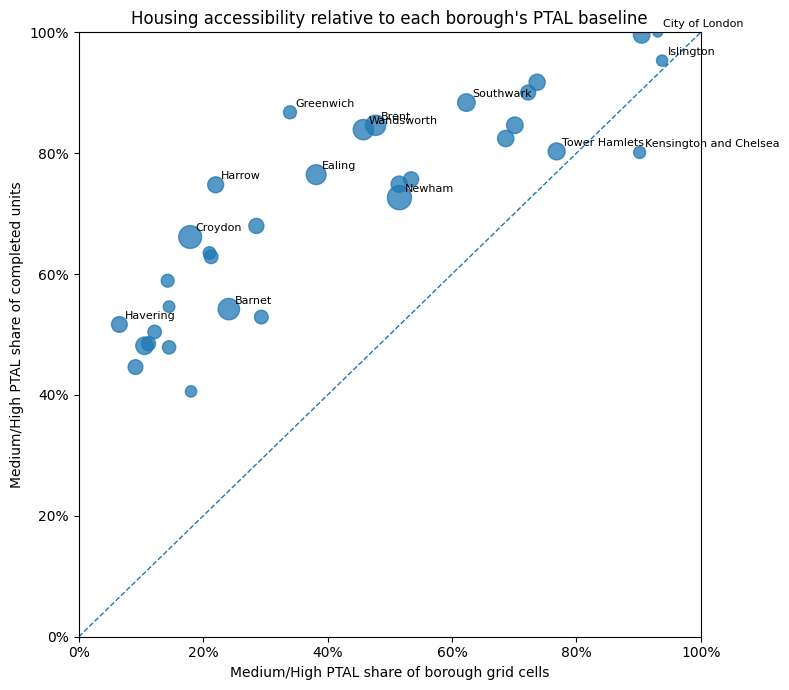

In [15]:
# Main borough-relative figure: observed completion share versus local grid baseline
plot_data = borough_relative.dropna(
    subset=["completed_share_medium_high", "grid_share_medium_high"]
).copy()

# Label high-volume boroughs and the strongest positive/negative differences.
high_volume = plot_data["completed_units"] >= plot_data["completed_units"].quantile(0.80)
high_positive = plot_data["difference_pp"] >= plot_data["difference_pp"].quantile(0.90)
low_difference = plot_data["difference_pp"] <= plot_data["difference_pp"].quantile(0.10)
plot_data["label_point"] = high_volume | high_positive | low_difference

fig, ax = plt.subplots(figsize=(8, 7))

sizes = 40 + 260 * (
    plot_data["completed_units"] / plot_data["completed_units"].max()
)

ax.scatter(
    plot_data["grid_share_medium_high"],
    plot_data["completed_share_medium_high"],
    s=sizes,
    alpha=0.75
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Medium/High PTAL share of borough grid cells")
ax.set_ylabel("Medium/High PTAL share of completed units")
ax.set_title("Housing accessibility relative to each borough's PTAL baseline")

for _, row in plot_data[plot_data["label_point"]].iterrows():
    ax.annotate(
        row["borough_spatial"],
        (
            row["grid_share_medium_high"],
            row["completed_share_medium_high"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04b_borough_relative_ptal_baseline_scatter.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


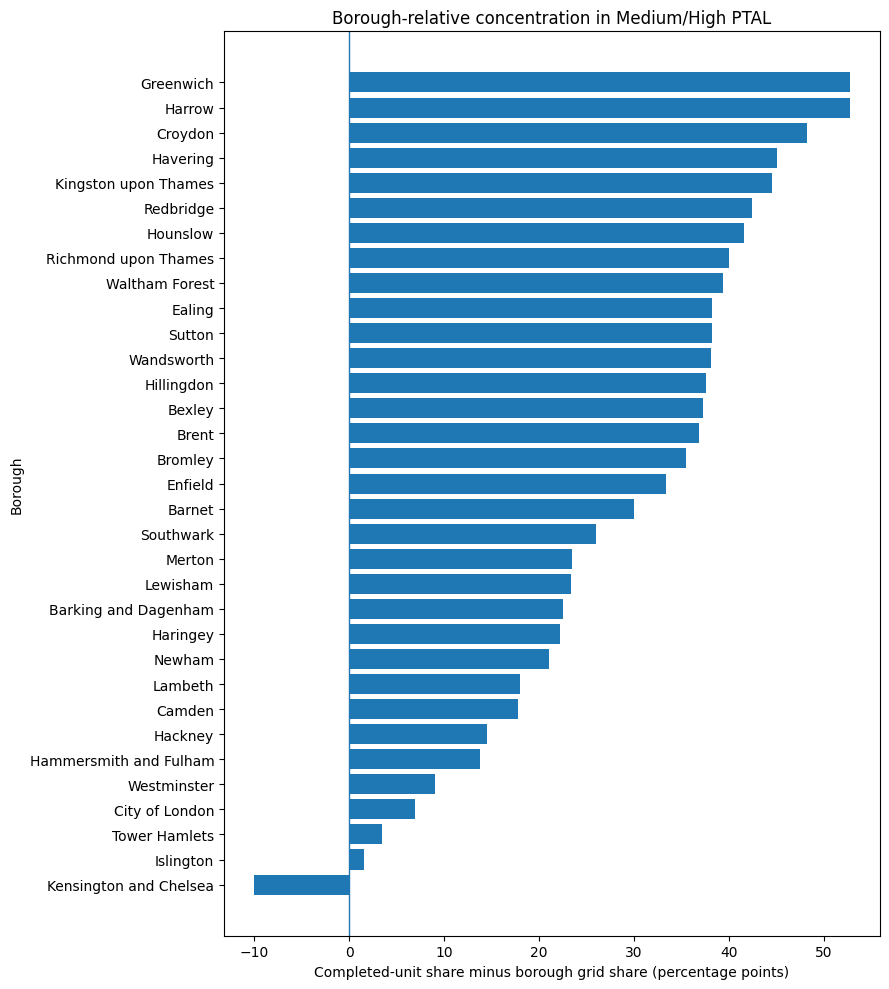

In [16]:
# Appendix-style ranking of relative alignment
bar_data = borough_relative.dropna(subset=["difference_pp"]).sort_values("difference_pp")

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(bar_data["borough_spatial"], bar_data["difference_pp"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("Completed-unit share minus borough grid share (percentage points)")
ax.set_ylabel("Borough")
ax.set_title("Borough-relative concentration in Medium/High PTAL")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04c_borough_relative_difference_pp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 3. Delivery volume and accessibility

The first figure restores the earlier absolute comparison. The second combines delivery volume with the borough-relative result.


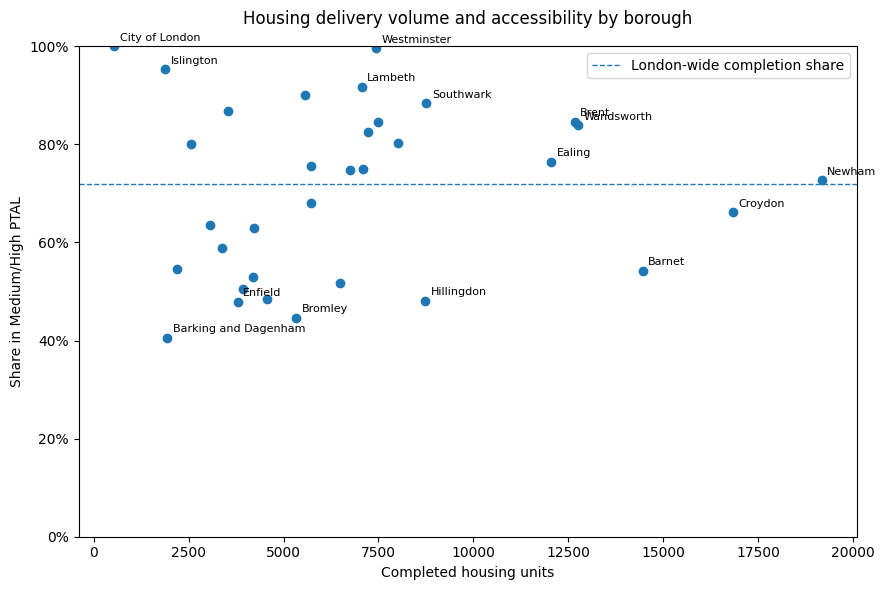

In [17]:
# Absolute accessibility share versus delivery volume
scatter_data = borough_relative.dropna(
    subset=["completed_units", "completed_share_medium_high"]
).copy()

high_volume = scatter_data["completed_units"] >= scatter_data["completed_units"].quantile(0.80)
high_access = (
    scatter_data["completed_share_medium_high"] >=
    scatter_data["completed_share_medium_high"].quantile(0.90)
)
low_access = (
    scatter_data["completed_share_medium_high"] <=
    scatter_data["completed_share_medium_high"].quantile(0.10)
)
scatter_data["label_point"] = high_volume | high_access | low_access

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    scatter_data["completed_units"],
    scatter_data["completed_share_medium_high"]
)

ax.axhline(
    housing.loc[housing["ptal_medium_high"].astype(bool), "completed_units"].sum() /
    housing["completed_units"].sum(),
    linestyle="--",
    linewidth=1,
    label="London-wide completion share"
)
ax.set_xlabel("Completed housing units")
ax.set_ylabel("Share in Medium/High PTAL")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 1)
ax.set_title(
    "Housing delivery volume and accessibility by borough",
    pad=16
)
ax.legend()

for _, row in scatter_data[scatter_data["label_point"]].iterrows():
    ax.annotate(
        row["borough_spatial"],
        (row["completed_units"], row["completed_share_medium_high"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04d_borough_units_vs_accessibility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


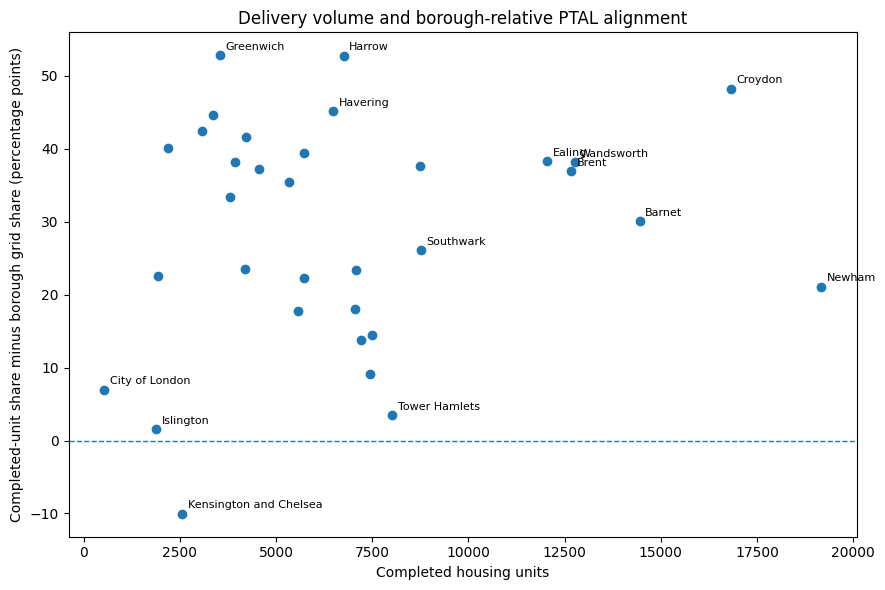

In [18]:
# Delivery volume versus relative alignment
relative_scatter = borough_relative.dropna(
    subset=["completed_units", "difference_pp"]
).copy()

label_mask = (
    (relative_scatter["completed_units"] >= relative_scatter["completed_units"].quantile(0.80)) |
    (relative_scatter["difference_pp"] >= relative_scatter["difference_pp"].quantile(0.90)) |
    (relative_scatter["difference_pp"] <= relative_scatter["difference_pp"].quantile(0.10))
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    relative_scatter["completed_units"],
    relative_scatter["difference_pp"]
)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Completed housing units")
ax.set_ylabel("Completed-unit share minus borough grid share (percentage points)")
ax.set_title("Delivery volume and borough-relative PTAL alignment")

for _, row in relative_scatter[label_mask].iterrows():
    ax.annotate(
        row["borough_spatial"],
        (row["completed_units"], row["difference_pp"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04e_borough_units_vs_relative_alignment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 4. Inner/Outer London stratification of the deprivation result

This tests whether the London-wide IMD gradient is mainly a consequence of the capital's inner–outer geography.

The notebook first looks for a previously exported record-level IMD GeoPackage. If it does not exist, it automatically finds the IMD 2019 Excel/CSV file and repeats the LSOA join.


In [19]:
IMD_JOINED_PATH = OUTPUT_DIR / "pld_completed_housing_with_ptal_imd_2019.gpkg"

if IMD_JOINED_PATH.exists():
    housing_imd = gpd.read_file(IMD_JOINED_PATH)
    print("Loaded existing record-level IMD file:", IMD_JOINED_PATH)
else:
    candidate_files = []
    for folder in [BASE, BASE / "data", OUTPUT_DIR]:
        if folder.exists():
            for pattern in [
                "*IMD*.csv", "*imd*.csv", "*deprivation*.csv",
                "*IMD*.xlsx", "*imd*.xlsx", "*deprivation*.xlsx",
                "*ID 2019*.xlsx"
            ]:
                candidate_files.extend(folder.glob(pattern))

    candidate_files = list(dict.fromkeys(candidate_files))
    print("Candidate IMD files:")
    for candidate in candidate_files:
        print("-", candidate)

    if not candidate_files:
        raise FileNotFoundError(
            "No IMD file was found. Put the IMD 2019 file in the notebook, data, "
            "or outputs folder, or export the joined record-level data from notebook 03."
        )

    IMD_PATH = candidate_files[0]
    print("Using IMD file:", IMD_PATH)

    if IMD_PATH.suffix.lower() in {".xlsx", ".xls"}:
        imd_raw = pd.read_excel(IMD_PATH)
    else:
        imd_raw = pd.read_csv(IMD_PATH)

    imd_cols = imd_raw.columns.tolist()

    imd_lsoa_col = find_col(
        imd_cols,
        [
            "lsoa11cd", "LSOA11CD", "LSOA code (2011)",
            "LSOA Code (2011)", "LSOA code", "LSOA Code"
        ]
    )
    if imd_lsoa_col is None:
        possible = [
            col for col in imd_cols
            if "lsoa" in str(col).lower()
            and ("code" in str(col).lower() or str(col).lower().endswith("cd"))
        ]
        if possible:
            imd_lsoa_col = possible[0]

    decile_col = find_col(
        imd_cols,
        [
            "Index of Multiple Deprivation (IMD) Decile",
            "IMD Decile", "imd_decile", "Decile"
        ]
    )
    rank_col = find_col(
        imd_cols,
        [
            "Index of Multiple Deprivation (IMD) Rank",
            "IMD Rank", "imd_rank", "Rank"
        ]
    )
    score_col = find_col(
        imd_cols,
        [
            "Index of Multiple Deprivation (IMD) Score",
            "IMD Score", "imd_score", "Score"
        ]
    )

    if imd_lsoa_col is None:
        raise ValueError(f"Could not detect the IMD LSOA column. Columns: {imd_cols}")
    if decile_col is None and rank_col is None and score_col is None:
        raise ValueError(f"Could not detect an IMD decile, rank or score column. Columns: {imd_cols}")

    imd = pd.DataFrame({
        "lsoa11cd": (
            imd_raw[imd_lsoa_col]
            .astype(str)
            .str.strip()
            .str.upper()
        )
    })

    if decile_col is not None:
        imd["imd_decile"] = pd.to_numeric(imd_raw[decile_col], errors="coerce")
        imd["imd_quintile"] = np.ceil(imd["imd_decile"] / 2).astype("Int64")
    elif rank_col is not None:
        imd["imd_rank"] = pd.to_numeric(imd_raw[rank_col], errors="coerce")
        imd["imd_quintile"] = pd.qcut(
            imd["imd_rank"].rank(method="first"),
            q=5,
            labels=[1, 2, 3, 4, 5]
        ).astype("Int64")
    else:
        imd["imd_score"] = pd.to_numeric(imd_raw[score_col], errors="coerce")
        imd["imd_quintile"] = pd.qcut(
            imd["imd_score"].rank(method="first", ascending=False),
            q=5,
            labels=[1, 2, 3, 4, 5]
        ).astype("Int64")

    imd = imd.drop_duplicates(subset=["lsoa11cd"]).copy()

    housing_imd = housing.merge(
        imd,
        on="lsoa11cd",
        how="left",
        validate="many_to_one"
    )

    print("Housing rows:", len(housing_imd))
    print("Rows without IMD:", housing_imd["imd_quintile"].isna().sum())

    # Save the joined record-level data for future reuse.
    housing_imd.to_file(
        IMD_JOINED_PATH,
        layer="housing_imd",
        driver="GPKG"
    )


Loaded existing record-level IMD file: outputs\pld_completed_housing_with_ptal_imd_2019.gpkg


In [20]:
# Attach Inner/Outer London classification from the borough boundary file
def classify_london_area(value):
    text = str(value).strip().upper()
    if text in {"T", "TRUE", "1", "INNER"}:
        return "Inner London"
    if text in {"F", "FALSE", "0", "OUTER"}:
        return "Outer London"
    return pd.NA

borough_area_lookup = (
    boroughs[["name", "ons_inner"]]
    .drop_duplicates(subset=["name"])
    .assign(london_area=lambda frame: frame["ons_inner"].map(classify_london_area))
    .set_index("name")["london_area"]
)

housing_imd["london_area"] = housing_imd["borough_spatial"].map(borough_area_lookup)
housing_imd["imd_quintile"] = pd.to_numeric(
    housing_imd["imd_quintile"],
    errors="coerce"
).astype("Int64")
housing_imd["imd_quintile_label"] = housing_imd["imd_quintile"].map({
    1: "Q1 most deprived",
    2: "Q2",
    3: "Q3",
    4: "Q4",
    5: "Q5 least deprived",
})
housing_imd["imd_quintile_label"] = pd.Categorical(
    housing_imd["imd_quintile_label"],
    categories=IMD_ORDER,
    ordered=True
)

print(housing_imd["london_area"].value_counts(dropna=False))


london_area
Outer London    15285
Inner London    10544
Name: count, dtype: int64


In [21]:
inner_outer_imd = (
    housing_imd
    .dropna(subset=["london_area", "imd_quintile_label"])
    .groupby(["london_area", "imd_quintile_label"], observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum"),
        units_medium_high=(
            "completed_units",
            lambda values: values[
                housing_imd.loc[values.index, "ptal_medium_high"].astype(bool)
            ].sum()
        ),
        units_high=(
            "completed_units",
            lambda values: values[
                housing_imd.loc[values.index, "ptal_high"].astype(bool)
            ].sum()
        )
    )
    .reset_index()
)

inner_outer_imd["share_medium_high"] = (
    inner_outer_imd["units_medium_high"] /
    inner_outer_imd["completed_units"]
)
inner_outer_imd["share_high"] = (
    inner_outer_imd["units_high"] /
    inner_outer_imd["completed_units"]
)

inner_outer_imd.to_csv(
    OUTPUT_DIR / "04_inner_outer_imd_accessibility.csv",
    index=False
)
inner_outer_imd


,london_area,imd_quintile_label,records,completed_units,units_medium_high,units_high,share_medium_high,share_high
0,Inner London,Q1 most deprived,1941,24151.0,20915.0,14475.0,0.866010,0.599354
1,Inner London,Q2,4324,44778.0,38082.0,24265.0,0.850462,0.541896
2,Inner London,Q3,2467,21347.0,15176.0,9984.0,0.710920,0.467700
3,Inner London,Q4,1336,8324.0,7595.0,6100.0,0.912422,0.732821
4,Inner London,Q5 least deprived,476,2660.0,2236.0,1152.0,0.840602,0.433083
5,Outer London,Q1 most deprived,1499,17381.0,11010.0,6070.0,0.633450,0.349232
6,Outer London,Q2,4198,44580.0,30283.0,16530.0,0.679296,0.370794
7,Outer London,Q3,4177,33432.0,22554.0,8009.0,0.674623,0.239561
8,Outer London,Q4,3151,19123.0,9306.0,2417.0,0.486639,0.126392
9,Outer London,Q5 least deprived,2260,9328.0,4488.0,566.0,0.481132,0.060678


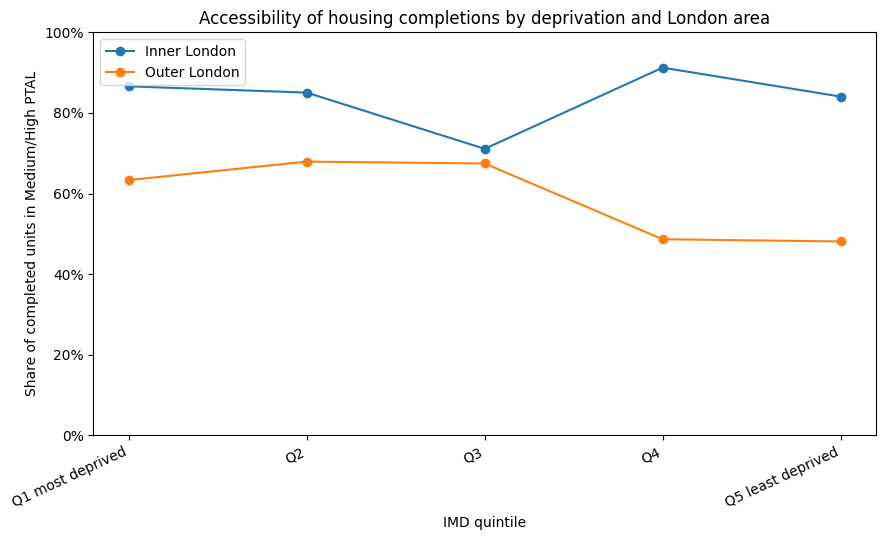

In [22]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for area in ["Inner London", "Outer London"]:
    area_data = (
        inner_outer_imd[inner_outer_imd["london_area"] == area]
        .set_index("imd_quintile_label")
        .reindex(IMD_ORDER)
    )

    ax.plot(
        IMD_ORDER,
        area_data["share_medium_high"],
        marker="o",
        label=area
    )

ax.set_ylim(0, 1)
ax.set_xlabel("IMD quintile")
ax.set_ylabel("Share of completed units in Medium/High PTAL")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title(
    "Accessibility of housing completions by deprivation and London area"
)
ax.legend()
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04f_inner_outer_imd_pattern.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## 5. Missing-data audit

This section requires the one-time `core_main` export from notebook 01.

It reports:

- scheme-size differences between matched and unmatched records;
- PTAL-valid coverage by financial year;
- PTAL-valid coverage by the source PLD borough field;
- the largest records excluded because of missing or unmatched postcodes.

The source borough field is used only for this audit because records without coordinates cannot be assigned spatially.


In [23]:
if not CORE_PATH.exists():
    raise FileNotFoundError(
        f"{CORE_PATH} does not exist. At the end of notebook 01, run:\n\n"
        "core_main.to_csv(OUTPUT_DIR / 'pld_core_main_2015_2025.csv', index=False)"
    )

core = pd.read_csv(CORE_PATH, low_memory=False)
core["completed_units"] = pd.to_numeric(core["completed_units"], errors="coerce")

required_core_cols = {
    "LPA Number", "Borough", "completed_units",
    "completion_financial_year", "postcode_clean"
}
missing_core_cols = required_core_cols.difference(core.columns)
if missing_core_cols:
    raise ValueError(f"Missing core-sample columns: {sorted(missing_core_cols)}")

print("Core records:", len(core))
print("Core units:", core["completed_units"].sum())


Core records: 27863
Core units: 296746.0


In [24]:
# Recheck ONSPD matching status for every core record.
onspd = pd.read_csv(
    ONSPD_PATH,
    usecols=["pcds"],
    dtype=str,
    encoding="utf-8-sig",
    low_memory=False
)

def normalise_postcode(series):
    return (
        series
        .astype("string")
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
        .replace({"<NA>": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    )

core["postcode_key"] = normalise_postcode(core["postcode_clean"])
onspd["postcode_key"] = normalise_postcode(onspd["pcds"])

onspd_lookup = (
    onspd[["postcode_key"]]
    .dropna()
    .drop_duplicates()
    .assign(onspd_match=True)
)

core_audit = core.merge(
    onspd_lookup,
    on="postcode_key",
    how="left",
    validate="many_to_one"
)

core_audit["spatial_status"] = "No extractable postcode"
core_audit.loc[
    core_audit["postcode_key"].notna(),
    "spatial_status"
] = "Postcode not matched to ONSPD"
matched_mask = (
    core_audit["onspd_match"]
    .astype("boolean")
    .fillna(False)
)

core_audit.loc[
    matched_mask,
    "spatial_status"
] = "Matched to ONSPD"
status_order = [
    "Matched to ONSPD",
    "No extractable postcode",
    "Postcode not matched to ONSPD",
]
core_audit["spatial_status"] = pd.Categorical(
    core_audit["spatial_status"],
    categories=status_order,
    ordered=True
)

status_summary = (
    core_audit
    .groupby("spatial_status", observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum"),
        mean_units=("completed_units", "mean"),
        median_units=("completed_units", "median"),
        p90_units=("completed_units", lambda values: values.quantile(0.90)),
        maximum_units=("completed_units", "max")
    )
    .reset_index()
)

status_summary["record_share"] = status_summary["records"] / status_summary["records"].sum()
status_summary["unit_share"] = (
    status_summary["completed_units"] /
    status_summary["completed_units"].sum()
)

status_summary.to_csv(
    OUTPUT_DIR / "04_missingness_scheme_size_summary.csv",
    index=False
)
status_summary


,spatial_status,records,completed_units,mean_units,median_units,p90_units,maximum_units,record_share,unit_share
0,Matched to ONSPD,25852,225451.0,8.720834,2.0,9.0,1465.0,0.927825,0.759744
1,No extractable postcode,1941,70089.0,36.109737,3.0,113.0,1260.0,0.069662,0.236192
2,Postcode not matched to ONSPD,70,1206.0,17.228571,2.0,8.1,443.0,0.002512,0.004064


In [25]:
# Annual PTAL-valid coverage: core totals versus the final analytical sample
annual_core = (
    core
    .groupby("completion_financial_year")
    .agg(
        core_records=("LPA Number", "count"),
        core_units=("completed_units", "sum")
    )
    .reset_index()
)

annual_valid = (
    housing
    .groupby("completion_financial_year")
    .agg(
        ptal_valid_records=("LPA Number", "count"),
        ptal_valid_units=("completed_units", "sum")
    )
    .reset_index()
)

annual_coverage = annual_core.merge(
    annual_valid,
    on="completion_financial_year",
    how="left"
).fillna({
    "ptal_valid_records": 0,
    "ptal_valid_units": 0
})

annual_coverage["record_coverage"] = (
    annual_coverage["ptal_valid_records"] /
    annual_coverage["core_records"]
)
annual_coverage["unit_coverage"] = (
    annual_coverage["ptal_valid_units"] /
    annual_coverage["core_units"]
)

annual_coverage = annual_coverage.sort_values("completion_financial_year")
annual_coverage.to_csv(
    OUTPUT_DIR / "04_annual_ptal_valid_coverage.csv",
    index=False
)
annual_coverage


,completion_financial_year,core_records,core_units,ptal_valid_records,ptal_valid_units,record_coverage,unit_coverage
0,2015/16,2955,25475.0,2744,19438.0,0.928596,0.763023
1,2016/17,4191,41183.0,3939,31610.0,0.939871,0.767550
2,2017/18,3445,33885.0,3285,26887.0,0.953556,0.793478
3,2018/19,3423,34050.0,3248,26279.0,0.948875,0.771777
4,2019/20,3364,35953.0,3176,27620.0,0.944114,0.768225
5,2020/21,2630,28463.0,2366,20720.0,0.899620,0.727963
6,2021/22,2781,30606.0,2490,21950.0,0.895361,0.717180
7,2022/23,887,13663.0,812,11068.0,0.915445,0.810071
8,2023/24,2363,29116.0,2117,21428.0,0.895895,0.735953
9,2024/25,1824,24352.0,1652,18104.0,0.905702,0.743430


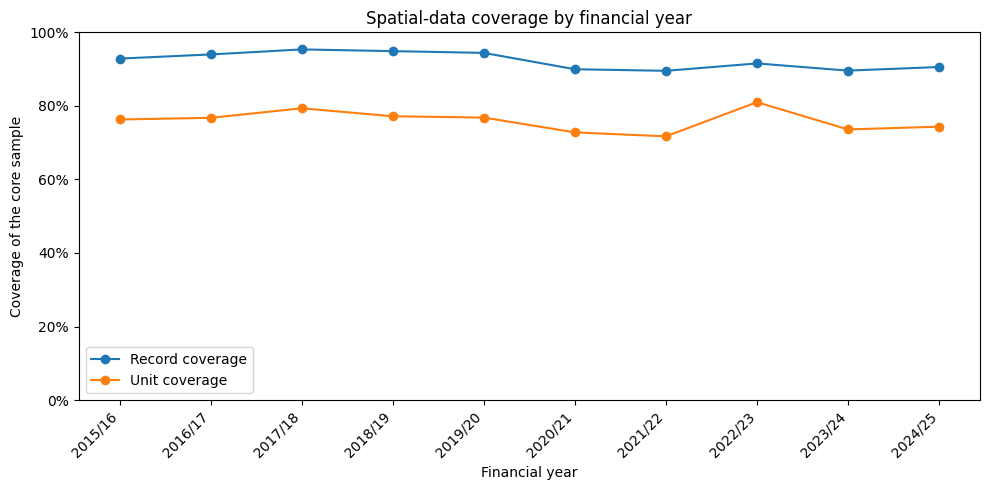

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    annual_coverage["completion_financial_year"],
    annual_coverage["record_coverage"],
    marker="o",
    label="Record coverage"
)
ax.plot(
    annual_coverage["completion_financial_year"],
    annual_coverage["unit_coverage"],
    marker="o",
    label="Unit coverage"
)

ax.set_ylim(0, 1)
ax.set_xlabel("Financial year")
ax.set_ylabel("Coverage of the core sample")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("Spatial-data coverage by financial year")
ax.legend()
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig04g_annual_record_and_unit_coverage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [27]:
import re

def clean_borough_name(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()
    text = text.replace("&", " and ")

    text = re.sub(r"\blondon borough of\b", " ", text)
    text = re.sub(r"\broyal borough of\b", " ", text)
    text = re.sub(r"\bborough council\b", " ", text)
    text = re.sub(r"\bcity council\b", " ", text)
    text = re.sub(r"\bcouncil\b", " ", text)

    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    aliases = {
        "city of westminster": "westminster",
        "westminster city": "westminster",
        "corporation of london": "city of london",
        "london corporation": "city of london",
    }

    return aliases.get(text, text)


official_borough_lookup = {
    clean_borough_name(name): name
    for name in boroughs["name"].dropna().unique()
}


core["borough_source_clean"] = (
    core["Borough"]
    .map(clean_borough_name)
    .map(official_borough_lookup)
)

housing["borough_source_clean"] = (
    housing["Borough"]
    .map(clean_borough_name)
    .map(official_borough_lookup)
)

In [28]:
print("Core rows without a standard borough name:")
print(core["borough_source_clean"].isna().sum())

print("\nHousing rows without a standard borough name:")
print(housing["borough_source_clean"].isna().sum())

print("\nUnmatched original authority names:")
print(
    core.loc[
        core["borough_source_clean"].isna(),
        "Borough"
    ]
    .value_counts()
    .head(30)
)

Core rows without a standard borough name:
344

Housing rows without a standard borough name:
330

Unmatched original authority names:
Borough
Richmond                               100
Kingston                                84
Royal Borough of Kingston (LA Code)     57
Bromley Custodian Code                  50
Out of Borough                          37
LB Bromley                              10
LLDC                                     4
Croydon SLA Code                         1
Name: count, dtype: int64


In [29]:
# Coverage by the original PLD Borough field.
# Use this as a data-quality audit, not as the main spatial borough comparison.

source_borough_core = (
    core
    .groupby("borough_source_clean", dropna=False)
    .agg(
        core_records=("LPA Number", "count"),
        core_units=("completed_units", "sum")
    )
    .reset_index()
)

source_borough_valid = (
    housing
    .groupby("borough_source_clean", dropna=False)
    .agg(
        ptal_valid_records=("LPA Number", "count"),
        ptal_valid_units=("completed_units", "sum")
    )
    .reset_index()
)

# 这里必须使用 borough_source_clean，而不是 Borough
source_borough_coverage = source_borough_core.merge(
    source_borough_valid,
    on="borough_source_clean",
    how="left",
    validate="one_to_one"
)

source_borough_coverage[
    ["ptal_valid_records", "ptal_valid_units"]
] = source_borough_coverage[
    ["ptal_valid_records", "ptal_valid_units"]
].fillna(0)

source_borough_coverage["record_coverage"] = (
    source_borough_coverage["ptal_valid_records"]
    / source_borough_coverage["core_records"]
)

source_borough_coverage["unit_coverage"] = (
    source_borough_coverage["ptal_valid_units"]
    / source_borough_coverage["core_units"]
)

source_borough_coverage = source_borough_coverage.sort_values(
    "unit_coverage"
)

source_borough_coverage.to_csv(
    OUTPUT_DIR / "04_source_borough_coverage_audit.csv",
    index=False
)

source_borough_coverage.head(15)

,borough_source_clean,core_records,core_units,ptal_valid_records,ptal_valid_units,record_coverage,unit_coverage
10,Greenwich,357,11856.0,307,3173.0,0.859944,0.267628
0,Barking and Dagenham,213,7110.0,167,1938.0,0.784038,0.272574
18,Islington,616,4618.0,261,1839.0,0.423701,0.398224
17,Hounslow,609,9383.0,367,4209.0,0.602627,0.448577
6,City of London,43,1227.0,36,572.0,0.837209,0.466178
29,Tower Hamlets,598,15976.0,468,7880.0,0.782609,0.493240
25,Redbridge,764,5097.0,617,3075.0,0.807592,0.603296
27,Southwark,1019,13856.0,930,8716.0,0.912659,0.629042
26,Richmond upon Thames,616,2496.0,528,1665.0,0.857143,0.667067
22,Lewisham,804,10684.0,769,7422.0,0.956468,0.694684


In [30]:
above_baseline = (
    borough_relative["difference_pp"] > 0
).sum()

below_baseline = (
    borough_relative["difference_pp"] < 0
).sum()

equal_baseline = (
    borough_relative["difference_pp"] == 0
).sum()

print("Boroughs above local PTAL baseline:", above_baseline)
print("Boroughs below local PTAL baseline:", below_baseline)
print("Boroughs equal to baseline:", equal_baseline)

Boroughs above local PTAL baseline: 32
Boroughs below local PTAL baseline: 1
Boroughs equal to baseline: 0


In [31]:
# Largest schemes excluded because of missing or unmatched postcodes
missing_schemes = core_audit[
    core_audit["spatial_status"] != "Matched to ONSPD"
].copy()

display_cols = [
    column for column in [
        "LPA Number", "Borough", "completion_financial_year",
        "completed_units", "Site name", "Street name", "Locality",
        "Postcode", "postcode_clean", "spatial_status"
    ]
    if column in missing_schemes.columns
]

largest_missing = (
    missing_schemes
    .sort_values("completed_units", ascending=False)
    [display_cols]
    .head(30)
)

largest_missing.to_csv(
    OUTPUT_DIR / "04_largest_spatially_unmatched_schemes.csv",
    index=False
)
largest_missing


,LPA Number,Borough,completion_financial_year,completed_units,Site name,Street name,Locality,Postcode,postcode_clean,spatial_status
4792,11/2366/O,Greenwich,2016/17,1260.0,"Kidbrooke Village, Phase 4",Kidbrooke Park Road,NaN,SE3,NaN,No extractable postcode
24841,H/01054/13,London Borough of Barnet,2023/24,1174.0,"West Hendon Estate, West Hendon, London, NW9",NaN,NaN,NaN,NaN,No extractable postcode
15964,16/0186/MA,Greenwich,2019/20,1007.0,"Plot N0205, N0206 and N0207",Peninsula Square,Greenwich,SE10,NaN,No extractable postcode
15928,14/00703/OUT,Barking and Dagenham,2023/24,968.0,Gascoigne Estate East,KING EDWARDS ROAD,NaN,NaN,NaN,No extractable postcode
4608,04/01230/OUT,London Borough of Barking and Dagenham,2016/17,818.0,Barking Riverside Area,RENWICK ROAD,Barking,NaN,NaN,No extractable postcode
3142,DC09/71246,Lewisham,2015/16,794.0,LAND ON SOUTH SIDE,LOAMPIT VALE,NaN,SE13,NaN,No extractable postcode
21534,PA/18/01525,Tower Hamlets,2021/22,767.0,Arrowhead Quay East,Of 163 Marsh Wall,NaN,E14,NaN,No extractable postcode
3000,10/02175/P,Croydon,2015/16,755.0,Saffron Square,Wellesley Road,Croydon,CR0,NaN,No extractable postcode
12282,14/2607/F,Greenwich,2020/21,751.0,Kidbrooke Village Phase 3,Kidbrooke Park Road,NaN,SE3,NaN,No extractable postcode
3105,13/3025,Greenwich,2018/19,661.0,Land at,Enderby Wharf,Greenwich,SE10,NaN,No extractable postcode


## Output inventory

### Key tables
- `04_borough_relative_ptal_baseline.csv`
- `04_inner_outer_imd_accessibility.csv`
- `04_missingness_scheme_size_summary.csv`
- `04_annual_ptal_valid_coverage.csv`
- `04_record_vs_unit_weighted_ptal.csv`

### Key figures
- `fig04b_borough_relative_ptal_baseline_scatter.png`
- `fig04d_borough_units_vs_accessibility.png`
- `fig04e_borough_units_vs_relative_alignment.png`
- `fig04f_inner_outer_imd_pattern.png`
- `fig04g_annual_record_and_unit_coverage.png`



In [32]:
# Check the exact record-weighted and unit-weighted PTAL percentages

check_ptal = (
    housing
    .groupby("ptal_band", observed=True)
    .agg(
        records=("LPA Number", "count"),
        completed_units=("completed_units", "sum")
    )
    .reindex(["Low", "Medium", "High"])
)

check_ptal["record_share_pct"] = (
    check_ptal["records"]
    / check_ptal["records"].sum()
    * 100
)

check_ptal["unit_share_pct"] = (
    check_ptal["completed_units"]
    / check_ptal["completed_units"].sum()
    * 100
)

print(check_ptal)
print("\nRounded to one decimal:")
print(check_ptal.round(1))

           records  completed_units  record_share_pct  unit_share_pct
ptal_band                                                            
Low           9142          63459.0         35.394324       28.190970
Medium        9426          72077.0         36.493863       32.019422
High          7261          89568.0         28.111812       39.789608

Rounded to one decimal:
           records  completed_units  record_share_pct  unit_share_pct
ptal_band                                                            
Low           9142          63459.0              35.4            28.2
Medium        9426          72077.0              36.5            32.0
High          7261          89568.0              28.1            39.8


In [33]:
high_units = housing.loc[
    housing["ptal_band"].astype(str) == "High",
    "completed_units"
].sum()

total_units = housing["completed_units"].sum()

print("High units:", high_units)
print("Total units:", total_units)
print("Exact share:", high_units / total_units * 100)
print("Rounded share:", round(high_units / total_units * 100, 1))

High units: 89568.0
Total units: 225104.0
Exact share: 39.789608358803044
Rounded share: 39.8
